# SKEMPI 2.0 — data dictionary

**What this notebook is.** A column-by-column orientation to the raw file, *before* any
filtering, any label construction, or any modelling decision. For each of the 29 columns it
answers four questions:

1. **What is it?** — the field's meaning and its units or encoding.
2. **How is it used in the literature?** — what published ΔΔG work does with it, and what it ignores.
3. **What values does it actually take?** — cardinality, completeness, and the full value set where that is small enough to print.
4. **What does it look like?** — a plot, so the distribution is visible rather than described.

It reads `data/skempi_v2.csv` and nothing else. All 7,085 rows, all four interaction types — the
antibody–antigen subset is one slice of this file and the last section shows where it sits.

The downstream analysis lives in [`01_eda.ipynb`](01_eda.ipynb); the decisions that came out of it
are in [`../EDA_FINDINGS.md`](../EDA_FINDINGS.md) and [`../PLAN.md`](../PLAN.md).

> **Two traps are documented at the end.** Both are ways of reading this file that look correct,
> produce no error, and give wrong answers. One of them silently mis-indexes two thirds of the
> dataset.

## 1. Setup

In [1]:
from pathlib import Path
import re, textwrap, collections

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
while not (ROOT / "data" / "skempi_v2.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

raw = pd.read_csv(ROOT / "data" / "skempi_v2.csv", sep=";", low_memory=False)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 70)

print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")

7,085 rows x 29 columns


In [2]:
# --- plotting: diverging where the quantity is signed, single hue otherwise ---
SURFACE, INK, INK_2, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, RED, NEUTRAL, ORANGE = "#2a78d6", "#e34948", "#c3c2b7", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "grid.color": GRID,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

def _ax(ax, title=""):
    ax.grid(axis="y", linewidth=0.8, zorder=0); ax.set_axisbelow(True)
    ax.tick_params(length=0)
    if title:
        ax.set_title(title, loc="left", fontsize=10.5, color=INK, pad=8)
    return ax

### The documentation table

Meaning and literature use are held in one dictionary so the helper below can print them next to
the live values. Keeping the prose in the same object as the code is what stops the two drifting.

In [3]:
# column -> (what it is, how the literature uses it)
DOCS = {
 "#Pdb": (
   "Complex identifier, formatted PDB_<side1 chains>_<side2 chains>. '3HFM_HL_Y' is PDB entry "
   "3HFM, with chains H+L on one side of the interface and chain Y on the other. It is both the "
   "key into the structure files and the definition of which interface was measured.",
   "The unit of the standard split. RDE-Network and DiffAffinity both run 3-fold CV grouped by "
   "structure, so no complex appears in two folds. Stricter work groups by sequence homology "
   "instead, because the same antigen recurs across different PDB entries."),
 "Mutation(s)_PDB": (
   "Mutation list in the numbering of the ORIGINAL PDB entry. Token format is "
   "<wild-type aa><chain><residue number><insertion code?><mutant aa>; multi-point mutations are "
   "comma-separated.",
   "Rarely the right column to use. See the numbering trap in section 9."),
 "Mutation(s)_cleaned": (
   "The same mutations renumbered to match the CLEANED structure files SKEMPI distributes in "
   "SKEMPI2_PDBs.tgz.",
   "This is the column essentially all downstream work uses, because it is the one that indexes "
   "correctly into the distributed structures."),
 "iMutation_Location(s)": (
   "Structural region of each mutated position, one code per position: COR (interface core), "
   "SUP (support), RIM (interface rim), INT (protein interior), SUR (non-interface surface). "
   "The classification is Levy (2010), based on relative solvent accessibility in the free "
   "monomer versus the complex.",
   "The standard stratification variable for error analysis. Binding hotspots concentrate in COR "
   "and SUP; SUR mutations are near-neutral for binding by construction, so a model that only "
   "looks good overall is often just exploiting this gradient."),
 "Hold_out_type": ("Interaction class: Pr/PI (protease-inhibitor), AB/AG (antibody-antigen), "
   "TCR/pMHC, or a comma-joined combination. Null on more than half the rows.",
   "How the antibody-antigen benchmark subset is selected. Also how papers report per-class "
   "breakdowns. Read section 9 before trusting the nulls."),
 "Hold_out_proteins": (
   "SKEMPI's own homology grouping: partner complexes that must be held out together to avoid "
   "over-estimating generalisation.",
   "The dataset authors' definition of homology, and the most defensible basis for a grouped "
   "split. Two interactions are deemed homologous if they share a binding partner, or have "
   "homologous partners, and share most interface residues."),
 "Affinity_mut (M)": (
   "Dissociation constant Kd of the MUTANT complex, in molar, as free text. May carry an "
   "inequality ('<1e-9') or the qualitative value 'n.b.' for no binding detected.",
   "Half of the label. Note the text form is the authoritative one; the parsed column silently "
   "discards the inequality."),
 "Affinity_mut_parsed": ("Numeric Kd of the mutant, parsed from the text column.",
   "What everyone actually reads. Inequalities become bare numbers here, which is a real hazard."),
 "Affinity_wt (M)": ("Dissociation constant of the WILD-TYPE complex, same text conventions.",
   "The reference point of the label."),
 "Affinity_wt_parsed": ("Numeric Kd of the wild type.", "As above."),
 "Temperature": (
   "Temperature of the affinity measurement in Kelvin, as free text. '298(assumed)' means the "
   "curators imputed the standard value because the source paper did not state one.",
   "Needed for the RT factor when converting Kd to free energy. Most published pipelines use a "
   "flat 298 K and ignore the column, which is a small systematic error on the rows measured "
   "at 277-310 K."),
 "kon_mut (M^(-1)s^(-1))": ("Association rate constant of the mutant complex.",
   "Largely unused for ddG prediction. Relevant to work separating binding kinetics from "
   "equilibrium affinity, where kon tracks long-range electrostatic steering."),
 "kon_mut_parsed": ("Numeric form of the same.", "As above."),
 "kon_wt (M^(-1)s^(-1))": ("Association rate constant of the wild-type complex.", "As above."),
 "kon_wt_parsed": ("Numeric form of the same.", "As above."),
 "koff_mut (s^(-1))": ("Dissociation rate constant of the mutant complex. Kd = koff / kon.",
   "Mostly unused, but koff is what many antibody-engineering campaigns actually optimise, since "
   "residence time rather than equilibrium Kd often drives potency."),
 "koff_mut_parsed": ("Numeric form of the same.", "As above."),
 "koff_wt (s^(-1))": ("Dissociation rate constant of the wild-type complex.", "As above."),
 "koff_wt_parsed": ("Numeric form of the same.", "As above."),
 "dH_mut (kcal mol^(-1))": ("Binding enthalpy of the mutant, from isothermal titration calorimetry.",
   "Almost never used in ddG prediction: available for well under a tenth of rows, and only from "
   "ITC. Its niche is enthalpy-entropy compensation analysis."),
 "dH_wt (kcal mol^(-1))": ("Binding enthalpy of the wild type.", "As above."),
 "dS_mut (cal mol^(-1) K^(-1))": ("Binding entropy of the mutant.", "As above."),
 "dS_wt (cal mol^(-1) K^(-1))": ("Binding entropy of the wild type.", "As above."),
 "Reference": ("PubMed identifier of the source publication.",
   "Under-used, and a genuine leakage axis: one paper often contributes an entire mutational "
   "scan of one complex, measured on one instrument by one group, so rows sharing a Reference "
   "are correlated in ways a random split will not respect."),
 "Protein 1": ("Free-text name of the first binding partner.",
   "Convenient for reading, unreliable for parsing. It does not dependably correspond to the "
   "first chain group in #Pdb."),
 "Protein 2": ("Free-text name of the second binding partner.", "As above."),
 "Method": ("Experimental technique used to measure affinity, as a SKEMPI abbreviation.",
   "The usual proxy for label noise. Different assays carry different systematic errors, so "
   "slicing model error by Method separates model failure from measurement failure."),
 "Notes": ("Curator free text. Flags non-native reference states, near-identical partner "
   "complexes, and assorted caveats.",
   "Almost universally ignored, and it should not be: it is where the curators recorded that a "
   "given 'wild type' is itself an affinity-matured variant."),
 "SKEMPI version": ("1 if the row was present in the original SKEMPI, 2 if added in SKEMPI 2.0.",
   "Useful for reproducing older papers, which benchmarked on version 1 only."),
}
print(f"{len(DOCS)} columns documented; file has {raw.shape[1]}")
assert set(DOCS) == set(raw.columns), set(raw.columns) ^ set(DOCS)

29 columns documented; file has 29


In [4]:
def describe(col, max_list=25, split_on=None, log=False, top=20):
    """Print meaning, literature use and live values for one column, then plot it."""
    what, lit = DOCS[col]
    s = raw[col]
    print("=" * 100)
    print(col)
    print("=" * 100)
    for label, body in (("WHAT", what), ("LITERATURE", lit)):
        print(f"{label}:")
        print(textwrap.fill(body, 96, initial_indent="  ", subsequent_indent="  "))
    vals = s.dropna()
    if split_on:
        vals = vals.astype(str).str.split(split_on).explode().str.strip()
        note = f" (split on '{split_on}', one entry per mutated position)"
    else:
        note = ""
    print(f"\nVALUES{note}:  dtype={s.dtype}  non-null={s.notna().sum():,} "
          f"({100 * s.notna().mean():.1f}%)  unique={vals.nunique():,}")
    vc = vals.value_counts()
    if vals.nunique() <= max_list:
        print("  full value set:")
        for k, v in vc.items():
            print(f"    {str(k):<22} {v:>6,}  {100 * v / len(vals):5.1f}%")
    else:
        print(f"  most frequent {min(top, len(vc))} of {vals.nunique():,}:")
        for k, v in vc.head(top).items():
            print(f"    {str(k)[:60]:<62} {v:>6,}")
    return vals, vc


def barplot(vc, title, xlabel="rows", color=BLUE, top=20, figsize=(8.2, None)):
    vc = vc.head(top)[::-1]
    h = figsize[1] or max(2.0, 0.26 * len(vc) + 0.9)
    fig, ax = plt.subplots(figsize=(figsize[0], h))
    _ax(ax, title); ax.grid(axis="y", linewidth=0)
    ax.grid(axis="x", linewidth=0.8); ax.set_axisbelow(True)
    ax.barh([str(i)[:38] for i in vc.index], vc.values, color=color, height=0.68, zorder=3)
    ax.set_xlabel(xlabel)
    for y, v in enumerate(vc.values):
        ax.text(v, y, f" {v:,}", va="center", fontsize=8.5, color=INK_2)
    fig.tight_layout(); plt.show()

## 2. The file at a glance

29 columns over 7,085 rows. The single most informative view is **completeness**: the columns
split into a dense core that every row has, and two sparse blocks — kinetics (~74% missing) and
calorimetry (~94% missing) — that are only populated when the source experiment happened to
measure them.

In [5]:
overview = pd.DataFrame([{
    "column": c, "dtype": str(raw[c].dtype), "non_null": raw[c].notna().sum(),
    "null_%": round(100 * raw[c].isna().mean(), 1), "unique": raw[c].nunique(),
    "example": " | ".join(raw[c].dropna().astype(str).head(2))[:46],
} for c in raw.columns])
overview

,column,dtype,non_null,null_%,unique,example
0,#Pdb,object,7085,0.0,348,1CSE_E_I | 1CSE_E_I
1,Mutation(s)_PDB,object,7085,0.0,4707,LI45G | LI45S
2,Mutation(s)_cleaned,object,7085,0.0,5635,LI38G | LI38S
3,iMutation_Location(s),object,7085,0.0,487,COR | COR
4,Hold_out_type,object,3311,53.3,4,Pr/PI | Pr/PI
5,Hold_out_proteins,object,7085,0.0,165,Pr/PI | Pr/PI
6,Affinity_mut (M),object,7085,0.0,2511,5.26E-11 | 8.33E-12
7,Affinity_mut_parsed,float64,6800,4.0,2472,5.26e-11 | 8.33e-12
8,Affinity_wt (M),object,7085,0.0,466,1.12E-12 | 1.12E-12
9,Affinity_wt_parsed,float64,7083,0.0,464,1.12e-12 | 1.12e-12


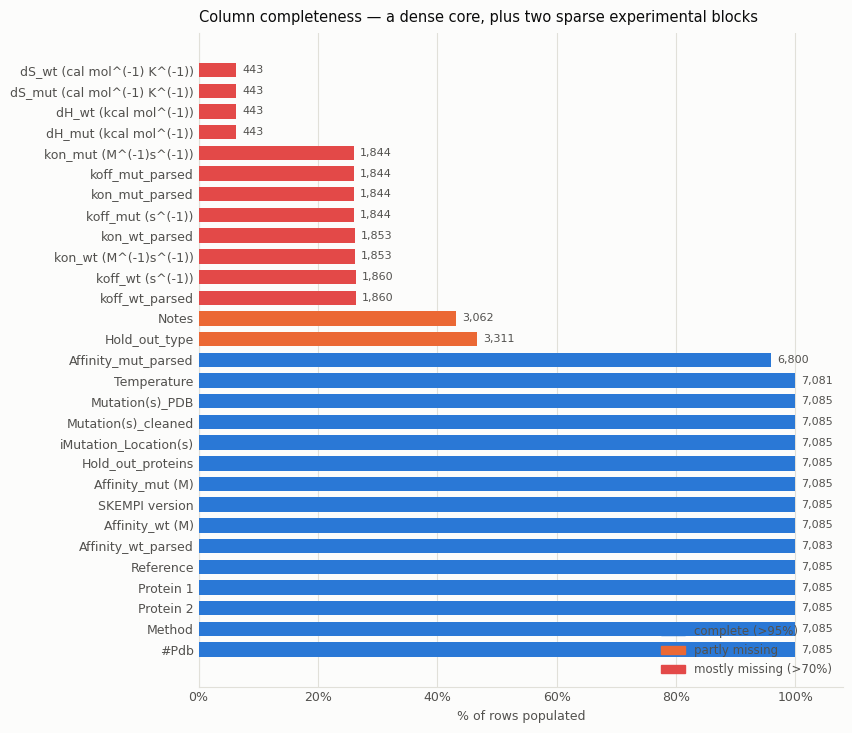

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 7.4))
_ax(ax, "Column completeness — a dense core, plus two sparse experimental blocks")
ax.grid(axis="y", linewidth=0); ax.grid(axis="x", linewidth=0.8); ax.set_axisbelow(True)
o = overview.sort_values("null_%")
cols = [RED if v > 70 else (ORANGE if v > 5 else BLUE) for v in o["null_%"]]
ax.barh(o["column"], 100 - o["null_%"], color=cols, height=0.7, zorder=3)
ax.set_xlabel("% of rows populated"); ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(PercentFormatter())
for y, (v, n) in enumerate(zip(100 - o["null_%"], o["non_null"])):
    ax.text(v + 1, y, f"{n:,}", va="center", fontsize=8, color=INK_2)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (BLUE, ORANGE, RED)]
ax.legend(handles, ["complete (>95%)", "partly missing", "mostly missing (>70%)"],
          frameon=False, fontsize=8.5, loc="lower right", labelcolor=INK_2)
fig.tight_layout(); plt.show()

## 3. Identity: which interface was measured

`#Pdb` is the backbone of the whole dataset. It names a PDB entry *and* partitions its chains
into the two sides of one interface — which matters because a PDB entry can contain several
distinct interfaces, and SKEMPI measures a specific one.

`SKEMPI version` separates the original 2012 release from the 2018 expansion.

#Pdb
WHAT:
  Complex identifier, formatted PDB_<side1 chains>_<side2 chains>. '3HFM_HL_Y' is PDB entry
  3HFM, with chains H+L on one side of the interface and chain Y on the other. It is both the
  key into the structure files and the definition of which interface was measured.
LITERATURE:
  The unit of the standard split. RDE-Network and DiffAffinity both run 3-fold CV grouped by
  structure, so no complex appears in two folds. Stricter work groups by sequence homology
  instead, because the same antigen recurs across different PDB entries.

VALUES:  dtype=object  non-null=7,085 (100.0%)  unique=348
  most frequent 12 of 348:
    1CHO_EFG_I                                                        295
    3SGB_E_I                                                          295
    1R0R_E_I                                                          284
    1JTG_A_B                                                          275
    1PPF_E_I                                                        

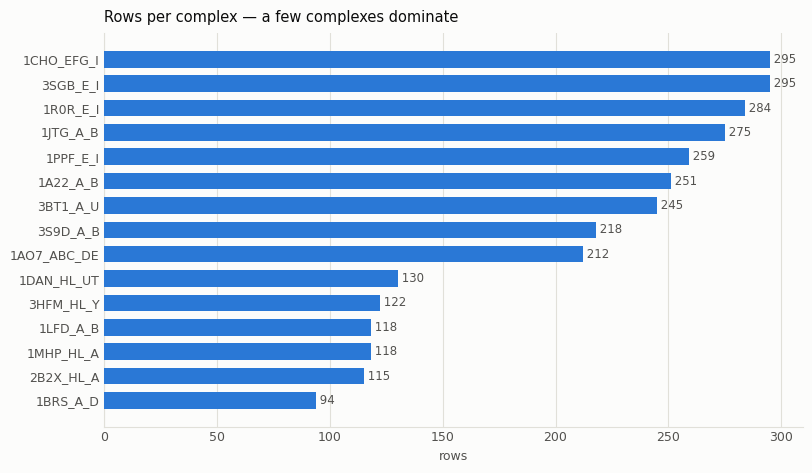

In [7]:
v, vc = describe("#Pdb", top=12)
print(f"\n  -> {vc.size} distinct complexes; the top 12 alone hold {vc.head(12).sum():,} rows "
      f"({100 * vc.head(12).sum() / len(raw):.0f}% of the file).")
barplot(vc, "Rows per complex — a few complexes dominate", top=15)

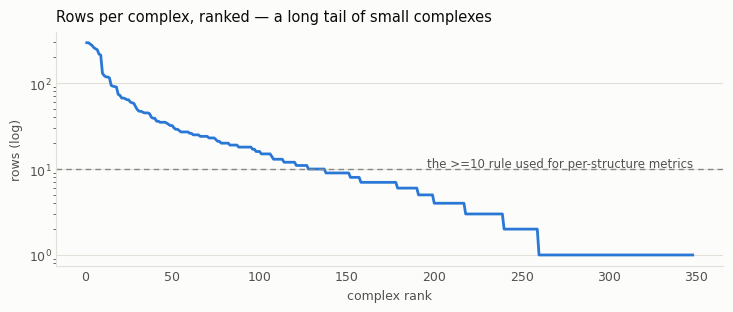

complexes with >=10 mutations: 137 of 348


In [8]:
fig, ax = plt.subplots(figsize=(7.4, 3.2))
_ax(ax, "Rows per complex, ranked — a long tail of small complexes")
ax.plot(range(1, len(vc) + 1), vc.values, color=BLUE, linewidth=2)
ax.set_yscale("log"); ax.set_xlabel("complex rank"); ax.set_ylabel("rows (log)")
ax.axhline(10, color=INK_MUTED, linestyle=(0, (4, 3)), linewidth=1)
ax.text(len(vc), 10.6, "the >=10 rule used for per-structure metrics", ha="right",
        fontsize=8.5, color=INK_2)
fig.tight_layout(); plt.show()
print(f"complexes with >=10 mutations: {(vc >= 10).sum()} of {vc.size}")

SKEMPI version
WHAT:
  1 if the row was present in the original SKEMPI, 2 if added in SKEMPI 2.0.
LITERATURE:
  Useful for reproducing older papers, which benchmarked on version 1 only.

VALUES:  dtype=int64  non-null=7,085 (100.0%)  unique=2
  full value set:
    2                       4,066   57.4%
    1                       3,019   42.6%


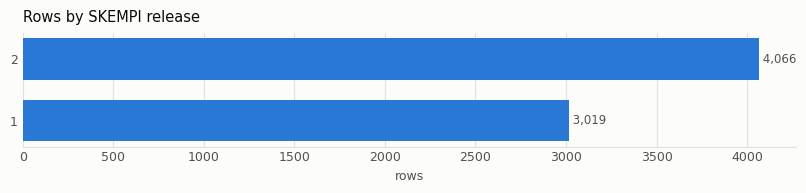

In [9]:
describe("SKEMPI version")
barplot(raw["SKEMPI version"].value_counts(), "Rows by SKEMPI release", color=BLUE)

## 4. The mutation: what was changed

Two columns encode the same mutations in two different numbering schemes, and a third annotates
where each mutated position sits structurally.

Token format is `<wild-type><chain><residue number><insertion code?><mutant>`, so `YH33A` reads
"tyrosine at position 33 of chain H, replaced by alanine". Insertion codes matter for antibodies,
whose numbering schemes deliberately use them (`TL30aS`).

Mutation(s)_cleaned
WHAT:
  The same mutations renumbered to match the CLEANED structure files SKEMPI distributes in
  SKEMPI2_PDBs.tgz.
LITERATURE:
  This is the column essentially all downstream work uses, because it is the one that indexes
  correctly into the distributed structures.

VALUES:  dtype=object  non-null=7,085 (100.0%)  unique=5,635
  most frequent 8 of 5,635:
    HA167A                                                             19
    AA167H                                                             19
    YC5A                                                               14
    RA65A                                                              10
    AA14H                                                              10
    HA14A                                                              10
    HA17A                                                              10
    AA17H                                                              10

  -> mutations per row: media

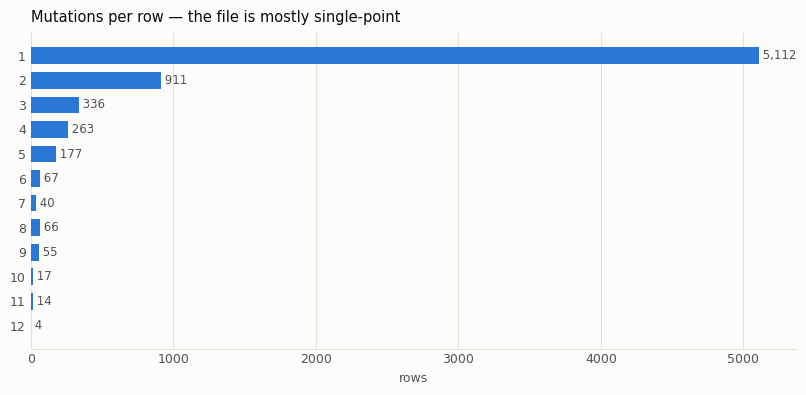

In [10]:
describe("Mutation(s)_cleaned", top=8)
n_mut = raw["Mutation(s)_cleaned"].str.count(",") + 1
print(f"\n  -> mutations per row: median {int(n_mut.median())}, max {n_mut.max()}")
barplot(n_mut.value_counts().sort_index(), "Mutations per row — the file is mostly single-point",
        xlabel="rows", top=12)

In [11]:
describe("Mutation(s)_PDB", top=6)
differ = raw["Mutation(s)_PDB"].astype(str) != raw["Mutation(s)_cleaned"].astype(str)
print(f"\n  -> the two numbering columns DISAGREE on {differ.sum():,} of {len(raw):,} rows "
      f"({100 * differ.mean():.1f}%). See section 9, trap 1.")

Mutation(s)_PDB
WHAT:
  Mutation list in the numbering of the ORIGINAL PDB entry. Token format is <wild-type
  aa><chain><residue number><insertion code?><mutant aa>; multi-point mutations are comma-
  separated.
LITERATURE:
  Rarely the right column to use. See the numbering trap in section 9.

VALUES:  dtype=object  non-null=7,085 (100.0%)  unique=4,707
  most frequent 6 of 4,707:
    HA180A                                                             19
    AA180H                                                             19
    YC5A                                                               14
    HA30A                                                              12
    HA27A                                                              11
    AA27H                                                              10

  -> the two numbering columns DISAGREE on 4,739 of 7,085 rows (66.9%). See section 9, trap 1.


iMutation_Location(s)
WHAT:
  Structural region of each mutated position, one code per position: COR (interface core), SUP
  (support), RIM (interface rim), INT (protein interior), SUR (non-interface surface). The
  classification is Levy (2010), based on relative solvent accessibility in the free monomer
  versus the complex.
LITERATURE:
  The standard stratification variable for error analysis. Binding hotspots concentrate in COR
  and SUP; SUR mutations are near-neutral for binding by construction, so a model that only
  looks good overall is often just exploiting this gradient.

VALUES (split on ',', one entry per mutated position):  dtype=object  non-null=7,085 (100.0%)  unique=5
  full value set:
    COR                     4,599   37.3%
    RIM                     2,687   21.8%
    SUR                     2,271   18.4%
    SUP                     1,615   13.1%
    INT                     1,152    9.3%


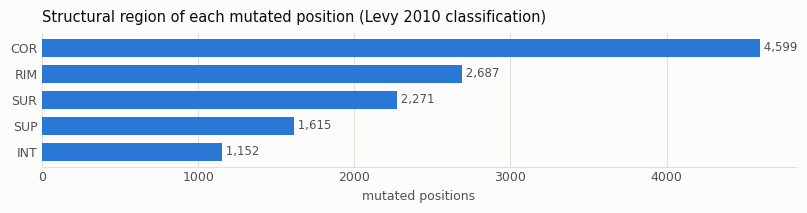

In [12]:
vals, vc = describe("iMutation_Location(s)", split_on=",")
barplot(vc, "Structural region of each mutated position (Levy 2010 classification)",
        xlabel="mutated positions", color=BLUE)

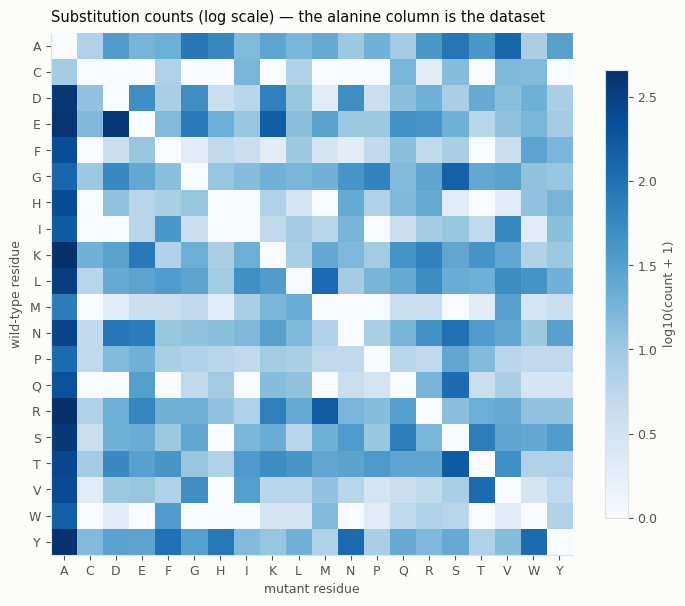

substitutions to alanine: 4,878 of 12,324 (39.6%)


In [13]:
# the substitution matrix: which amino acid becomes which
TOK = re.compile(r"^([A-Z])([A-Za-z])(-?\d+)([a-zA-Z]?)([A-Z])$")
AAS = list("ACDEFGHIKLMNPQRSTVWY")
pairs = collections.Counter()
for cell in raw["Mutation(s)_cleaned"].astype(str):
    for tok in cell.split(","):
        m = TOK.match(tok.strip())
        if m: pairs[(m.group(1), m.group(5))] += 1
M = np.zeros((20, 20))
for (a, b), n in pairs.items():
    if a in AAS and b in AAS: M[AAS.index(a), AAS.index(b)] = n
fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(np.log10(M + 1), cmap="Blues")
ax.set_xticks(range(20), AAS); ax.set_yticks(range(20), AAS)
ax.set_xlabel("mutant residue"); ax.set_ylabel("wild-type residue")
ax.set_title("Substitution counts (log scale) — the alanine column is the dataset",
             loc="left", fontsize=10.5, color=INK, pad=8)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="log10(count + 1)")
fig.tight_layout(); plt.show()
to_ala = sum(n for (a, b), n in pairs.items() if b == "A")
print(f"substitutions to alanine: {to_ala:,} of {sum(pairs.values()):,} "
      f"({100 * to_ala / sum(pairs.values()):.1f}%)")

## 5. The label: affinity, and the free energy derived from it

SKEMPI does **not** ship ΔΔG. It ships two dissociation constants, and every paper derives the
label the same way:

$$\Delta\Delta G = RT \ln\!\left(\frac{K_{d,\mathrm{mut}}}{K_{d,\mathrm{wt}}}\right)$$

with $R = 1.987\times10^{-3}$ kcal mol⁻¹ K⁻¹. Positive ΔΔG means the mutant binds **worse**.

Two things to note. The sign convention is not universal — some papers define it with the ratio
inverted, so a reported correlation can be sign-flipped relative to this one. And each affinity
appears twice: once as authoritative free text, once as a parsed float that drops the inequality.

In [14]:
describe("Affinity_wt (M)", top=6)
describe("Affinity_mut (M)", top=6)
for c in ["Affinity_mut (M)", "Affinity_wt (M)"]:
    s = raw[c].astype(str)
    print(f"\n{c}: inequality (< or >) on {s.str.contains('[<>]').sum():,} rows; "
          f"'n.b.' (no binding) on {s.str.contains('n.b', case=False).sum():,} rows")

Affinity_wt (M)
WHAT:
  Dissociation constant of the WILD-TYPE complex, same text conventions.
LITERATURE:
  The reference point of the label.

VALUES:  dtype=object  non-null=7,085 (100.0%)  unique=466
  most frequent 6 of 466:
    5.26E-12                                                          281
    1.79E-11                                                          280
    2.94E-11                                                          275
    1.64E-10                                                          254
    4.6E-10                                                           241
    3E-09                                                             166
Affinity_mut (M)
WHAT:
  Dissociation constant Kd of the MUTANT complex, in molar, as free text. May carry an
  inequality ('<1e-9') or the qualitative value 'n.b.' for no binding detected.
LITERATURE:
  Half of the label. Note the text form is the authoritative one; the parsed column silently
  discards the inequality.

VALU

Affinity_wt_parsed
WHAT:
  Numeric Kd of the wild type.
LITERATURE:
  As above.

VALUES:  dtype=float64  non-null=7,083 (100.0%)  unique=464
  most frequent 20 of 464:
    5.26e-12                                                          281
    1.79e-11                                                          280
    2.94e-11                                                          275
    1.64e-10                                                          254
    4.6e-10                                                           241
    3e-09                                                             166
    8.5e-09                                                           127
    4.77e-09                                                          125
    3.4e-10                                                           119
    1.46e-09                                                          115
    3.4e-08                                                            93
    2.5e-09       

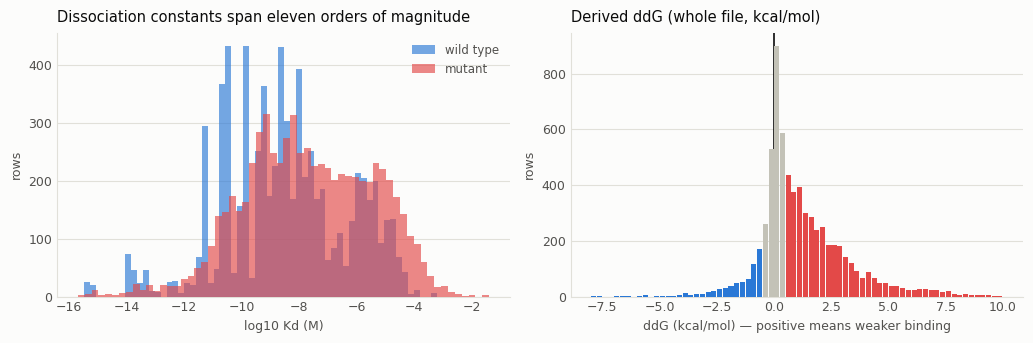

ddG computable on 6,798 of 7,085 rows; 75.9% are destabilising


In [15]:
describe("Affinity_wt_parsed"); describe("Affinity_mut_parsed")
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.5))
_ax(axes[0], "Dissociation constants span eleven orders of magnitude")
for v, c, lab in [(raw["Affinity_wt_parsed"], BLUE, "wild type"),
                  (raw["Affinity_mut_parsed"], RED, "mutant")]:
    axes[0].hist(np.log10(v.dropna()), bins=60, color=c, alpha=0.65, label=lab, zorder=3)
axes[0].set_xlabel("log10 Kd (M)"); axes[0].set_ylabel("rows")
axes[0].legend(frameon=False, fontsize=8.5, labelcolor=INK_2)

R = 1.987204e-3
T = raw["Temperature"].astype(str).str.extract(r"(\d+)")[0].astype(float).fillna(298.0)
ddg = R * T * np.log(raw["Affinity_mut_parsed"] / raw["Affinity_wt_parsed"])
_ax(axes[1], "Derived ddG (whole file, kcal/mol)")
edges = np.arange(-8, 10.25, 0.25)
cts, edges = np.histogram(ddg.dropna(), bins=edges)
ctr = (edges[:-1] + edges[1:]) / 2
axes[1].bar(ctr, cts, width=0.22,
            color=[BLUE if x < -0.5 else (RED if x > 0.5 else NEUTRAL) for x in ctr], zorder=3)
axes[1].axvline(0, color=INK, linewidth=1.2)
axes[1].set_xlabel("ddG (kcal/mol) — positive means weaker binding"); axes[1].set_ylabel("rows")
fig.tight_layout(); plt.show()
print(f"ddG computable on {ddg.notna().sum():,} of {len(raw):,} rows; "
      f"{100 * (ddg.dropna() > 0).mean():.1f}% are destabilising")

Temperature
WHAT:
  Temperature of the affinity measurement in Kelvin, as free text. '298(assumed)' means the
  curators imputed the standard value because the source paper did not state one.
LITERATURE:
  Needed for the RT factor when converting Kd to free energy. Most published pipelines use a
  flat 298 K and ignore the column, which is a small systematic error on the rows measured at
  277-310 K.

VALUES:  dtype=object  non-null=7,081 (99.9%)  unique=25
  full value set:
    298                     2,506   35.4%
    298(assumed)            2,351   33.2%
    294                     1,145   16.2%
    293                       344    4.9%
    303                       136    1.9%
    310                       113    1.6%
    295                       112    1.6%
    308                       111    1.6%
    296                        78    1.1%
    277                        36    0.5%
    305                        29    0.4%
    283                        29    0.4%
    299         

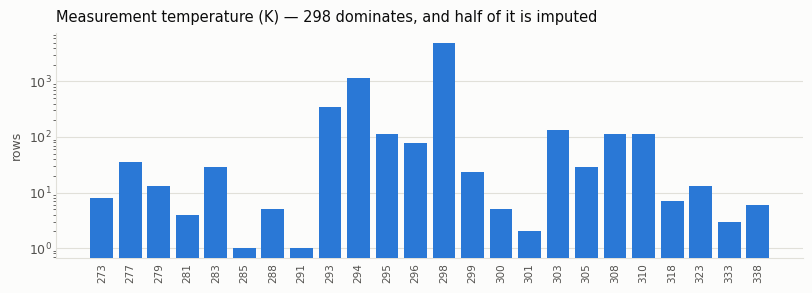

In [16]:
describe("Temperature")
tv = raw["Temperature"].astype(str)
assumed = tv.str.contains("assumed")
print(f"\n  -> {assumed.sum():,} rows ({100 * assumed.mean():.1f}%) carry an ASSUMED temperature.")
vc = tv.str.extract(r"(\d+)")[0].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8.2, 3.0))
_ax(ax, "Measurement temperature (K) — 298 dominates, and half of it is imputed")
ax.bar(range(len(vc)), vc.values, color=BLUE, zorder=3)
ax.set_xticks(range(len(vc)), vc.index, rotation=90, fontsize=7.5)
ax.set_ylabel("rows"); ax.set_yscale("log")
fig.tight_layout(); plt.show()

## 6. Kinetics and calorimetry: the sparse columns

Eight kinetic and four calorimetric columns. Kd = k_off / k_on, so the kinetic pair is a finer
decomposition of the same equilibrium the affinity columns describe — when it is present at all.

For ΔΔG prediction these are effectively unused, and the completeness chart shows why: any model
trained on them would be trained on a quarter of the data at best. They are worth knowing about
because k_off is frequently what antibody engineering actually optimises, and because a
kinetics-aware model is an obvious extension that the data does not currently support.

In [17]:
for c in ["kon_wt (M^(-1)s^(-1))", "koff_wt (s^(-1))", "dH_wt (kcal mol^(-1))"]:
    describe(c, top=5); print()

kon_wt (M^(-1)s^(-1))
WHAT:
  Association rate constant of the wild-type complex.
LITERATURE:
  As above.

VALUES:  dtype=float64  non-null=1,853 (26.2%)  unique=185
  most frequent 5 of 185:
    398000.0                                                          240
    340000.0                                                           73
    41000.0                                                            63
    67000.0                                                            60
    7700000.0                                                          50

koff_wt (s^(-1))
WHAT:
  Dissociation rate constant of the wild-type complex.
LITERATURE:
  As above.

VALUES:  dtype=object  non-null=1,860 (26.3%)  unique=185
  most frequent 5 of 185:
    1.77E-04                                                          240
    2.1E-03                                                           111
    1.5E-04                                                            64
    1E-01                   

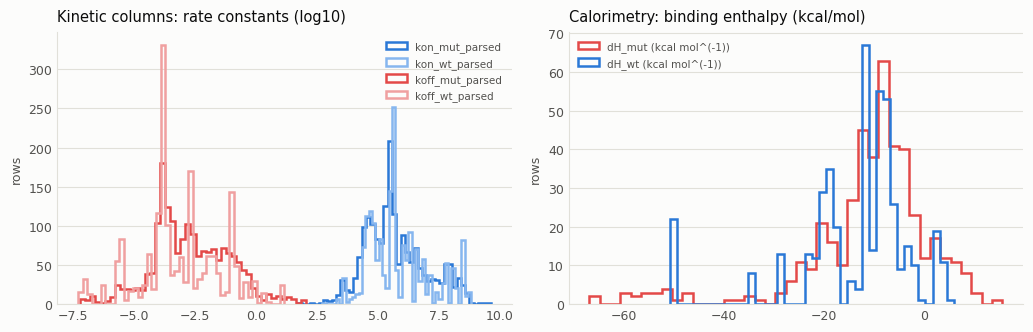

rows with ANY kinetic value: 1860 (26.3%)
rows with ANY calorimetry : 443 (6.3%)


In [18]:
kin = ["kon_mut_parsed", "kon_wt_parsed", "koff_mut_parsed", "koff_wt_parsed"]
thermo = ["dH_mut (kcal mol^(-1))", "dH_wt (kcal mol^(-1))",
          "dS_mut (cal mol^(-1) K^(-1))", "dS_wt (cal mol^(-1) K^(-1))"]
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.4))
_ax(axes[0], "Kinetic columns: rate constants (log10)")
for c, col in zip(kin[:2] + kin[2:], [BLUE, "#86b6ef", RED, "#f0a0a0"]):
    v = raw[c].dropna(); v = v[v > 0]
    axes[0].hist(np.log10(v), bins=45, histtype="step", linewidth=1.8, color=col, label=c)
axes[0].legend(frameon=False, fontsize=7.5, labelcolor=INK_2); axes[0].set_ylabel("rows")
_ax(axes[1], "Calorimetry: binding enthalpy (kcal/mol)")
for c, col in zip(thermo[:2], [RED, BLUE]):
    axes[1].hist(raw[c].dropna(), bins=40, histtype="step", linewidth=1.8, color=col, label=c)
axes[1].legend(frameon=False, fontsize=7.5, labelcolor=INK_2); axes[1].set_ylabel("rows")
fig.tight_layout(); plt.show()
print("rows with ANY kinetic value: %d (%.1f%%)" % (raw[kin].notna().any(axis=1).sum(),
      100 * raw[kin].notna().any(axis=1).mean()))
print("rows with ANY calorimetry : %d (%.1f%%)" % (raw[thermo].notna().any(axis=1).sum(),
      100 * raw[thermo].notna().any(axis=1).mean()))

## 7. Benchmark grouping: the two hold-out columns

These two columns exist for one purpose, stated in the SKEMPI 2.0 paper: to let people build
splits that do not over-estimate generalisation. Two interactions are deemed homologous if they
share a binding partner, or have homologous partners, and share most of their interface residues.

They are also the most confusingly encoded pair in the file — see trap 2 in section 9.

In [19]:
describe("Hold_out_type")
describe("Hold_out_proteins", top=12)

Hold_out_type
WHAT:
  Interaction class: Pr/PI (protease-inhibitor), AB/AG (antibody-antigen), TCR/pMHC, or a comma-
  joined combination. Null on more than half the rows.
LITERATURE:
  How the antibody-antigen benchmark subset is selected. Also how papers report per-class
  breakdowns. Read section 9 before trusting the nulls.

VALUES:  dtype=object  non-null=3,311 (46.7%)  unique=4
  full value set:
    Pr/PI                   1,349   40.7%
    AB/AG                   1,149   34.7%
    TCR/pMHC                  751   22.7%
    AB/AG,Pr/PI                62    1.9%
Hold_out_proteins
WHAT:
  SKEMPI's own homology grouping: partner complexes that must be held out together to avoid
  over-estimating generalisation.
LITERATURE:
  The dataset authors' definition of homology, and the most defensible basis for a grouped
  split. Two interactions are deemed homologous if they share a binding partner, or have
  homologous partners, and share most interface residues.

VALUES:  dtype=object  non

(0                   Pr/PI
 1                   Pr/PI
 2                   Pr/PI
 3                   Pr/PI
 4                   Pr/PI
               ...        
 7080    TCR/pMHC,1JCK_A_B
 7081    TCR/pMHC,1JCK_A_B
 7082    TCR/pMHC,1JCK_A_B
 7083    TCR/pMHC,1JCK_A_B
 7084    TCR/pMHC,1JCK_A_B
 Name: Hold_out_proteins, Length: 7085, dtype: object,
 Hold_out_proteins
 Pr/PI                                                                      1349
 AB/AG                                                                      1062
 TCR/pMHC,1JCK_A_B                                                           642
 1XXM_A_C,1S0W_A_C,1JTG_A_B,2G2U_A_B,2G2W_A_B,3N4I_A_B,1JTD_A_B,3QHY_A_B     277
 1A22_A_B,1BP3_A_B                                                           251
                                                                            ... 
 4GU0_A_E                                                                      1
 2ABZ_B_E,4CPA_A_I                                            

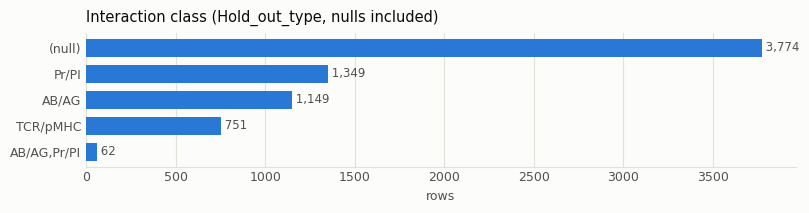

In [20]:
ht = raw["Hold_out_type"].fillna("(null)")
barplot(ht.value_counts(), "Interaction class (Hold_out_type, nulls included)", color=BLUE)

## 8. Provenance and curation

Where the number came from, how it was measured, and what the curators wanted you to know.

`Method` is the standard proxy for label noise. `Reference` is an under-used leakage axis: a
single paper typically contributes an entire mutational scan of one complex, measured on one
instrument by one group. `Notes` is where the curators recorded caveats that change how a row
should be interpreted, including the ones that say a given "wild type" is itself a mutant.

Method
WHAT:
  Experimental technique used to measure affinity, as a SKEMPI abbreviation.
LITERATURE:
  The usual proxy for label noise. Different assays carry different systematic errors, so
  slicing model error by Method separates model failure from measurement failure.

VALUES:  dtype=object  non-null=7,085 (100.0%)  unique=20
  full value set:
    SPR                     2,655   37.5%
    FL                      1,438   20.3%
    ITC                       557    7.9%
    IASP                      481    6.8%
    RA                        363    5.1%
    SFFL                      354    5.0%
    SP                        324    4.6%
    ELISA                     265    3.7%
    IAFL                      184    2.6%
    IARA                      132    1.9%
    KinExA                    129    1.8%
    BI                         64    0.9%
    CSPRIA                     44    0.6%
    ELFA                       25    0.4%
    ESMA                       22    0.3%
    SE             

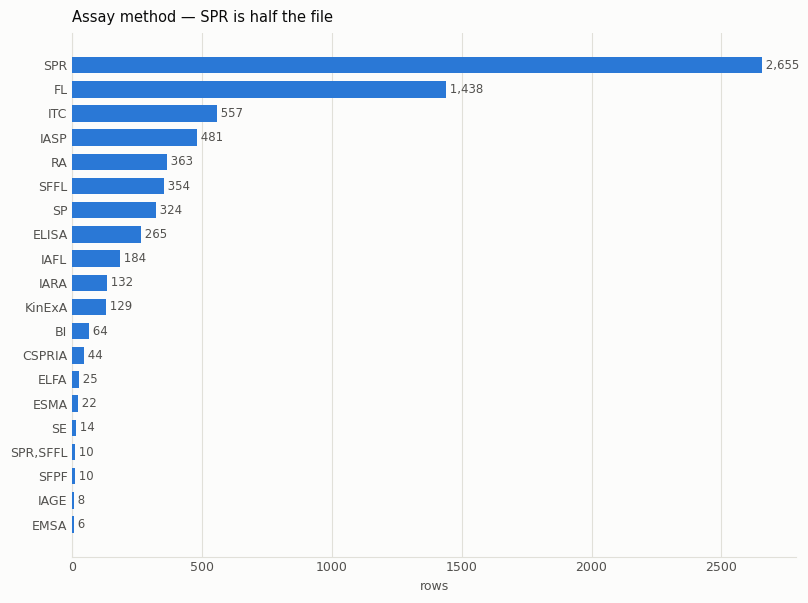

In [21]:
vals, vc = describe("Method")
barplot(vc, "Assay method — SPR is half the file", color=BLUE, top=20)

Reference
WHAT:
  PubMed identifier of the source publication.
LITERATURE:
  Under-used, and a genuine leakage axis: one paper often contributes an entire mutational scan
  of one complex, measured on one instrument by one group, so rows sharing a Reference are
  correlated in ways a random split will not respect.

VALUES:  dtype=object  non-null=7,085 (100.0%)  unique=295
  most frequent 8 of 295:
    11171964                                                          684
    Stephen Ming-teh Lu, PhD Thesis, Purdue University, 2000          330
    16672229                                                          240
    16597831                                                          233
    15236966                                                          160
    21854986                                                          142
    20889499                                                          139
    23736024                                                          136

  -> 

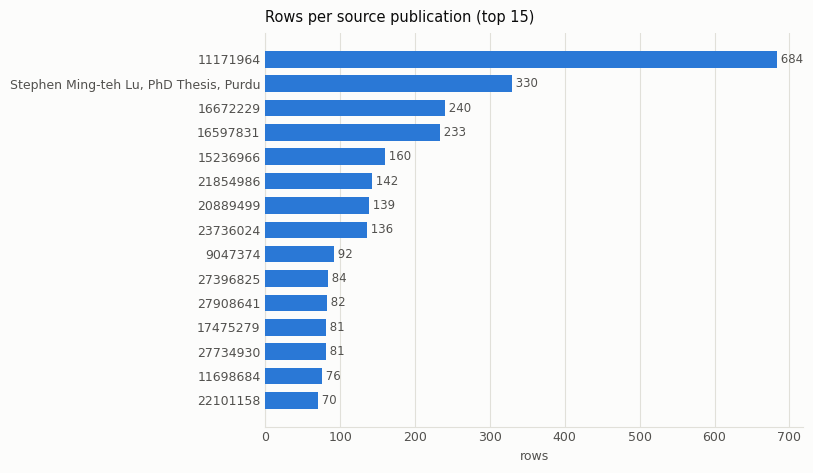

In [22]:
describe("Reference", top=8)
rc = raw["Reference"].value_counts()
print(f"\n  -> {rc.size} publications; median {int(rc.median())} rows each, max {rc.max()}.")
print("     Rows sharing a Reference are correlated: same group, same instrument, same complex.")
barplot(rc, "Rows per source publication (top 15)", color=BLUE, top=15)

In [23]:
describe("Protein 1", top=8); describe("Protein 2", top=8)

Protein 1
WHAT:
  Free-text name of the first binding partner.
LITERATURE:
  Convenient for reading, unreliable for parsing. It does not dependably correspond to the first
  chain group in #Pdb.

VALUES:  dtype=object  non-null=7,085 (100.0%)  unique=181
  most frequent 8 of 181:
    Bovine alpha-chymotrypsin                                         353
    Human growth hormone                                              317
    TEM-1 beta-lactamase                                              313
    Streptomyces griseus proteinase B                                 311
    Subtilisin Carlsberg                                              290
    Interferon alpha-2                                                287
    HLA-A2 plus tax peptide                                           267
    Human leukocyte elastase                                          259
Protein 2
WHAT:
  Free-text name of the second binding partner.
LITERATURE:
  As above.

VALUES:  dtype=object  non-null=7,085 

(0       Eglin c
 1       Eglin c
 2       Eglin c
 3       Eglin c
 4       Eglin c
          ...   
 7080    2B4 TCR
 7081    2B4 TCR
 7082    2B4 TCR
 7083    2B4 TCR
 7084    2B4 TCR
 Name: Protein 2, Length: 7085, dtype: object,
 Protein 2
 Turkey ovomucoid third domain    1149
 BLIP                              326
 HEW Lysozyme                      301
 hGH binding protein               251
 A6 TCR                            246
                                  ... 
 Ehp                                 1
 DhaR(N)                             1
 SmacN                               1
 Invasin ipaA                        1
 Neurexin-1-beta                     1
 Name: count, Length: 192, dtype: int64)

In [24]:
describe("Notes", top=6)
notes = raw["Notes"].fillna("")
flags = {
  "non-native reference state (wt is itself matured/mutant)":
      notes.str.contains(r"affinity[- ]matured|taken as wild[- ]?type", case=False, regex=True),
  "curator flags a near-identical partner complex":
      notes.str.contains(r"very similar|nearly identical|almost identical", case=False, regex=True),
  "mentions a crystal structure caveat": notes.str.contains("crystal structure", case=False),
}
print()
for k, v in flags.items():
    print(f"  {v.sum():>5,} rows ({100 * v.mean():4.1f}%)  {k}")

Notes
WHAT:
  Curator free text. Flags non-native reference states, near-identical partner complexes, and
  assorted caveats.
LITERATURE:
  Almost universally ignored, and it should not be: it is where the curators recorded that a
  given 'wild type' is itself an affinity-matured variant.

VALUES:  dtype=object  non-null=3,062 (43.2%)  unique=295
  most frequent 6 of 295:
    CS is the G120R mutant, which is away from the binding site       274
    The crystal structure contains the HEQ IFNa2 varient, and th      199
    NB) HyHEL-10 and HyHEL-63 are very similar,,                      155
    Crystal structure is one of the mutants in the paper. This m      142
    Crystal structure is one of the mutants in the paper. This m      115
    Crystal structure is the affinity matured fab reported in th      113

    167 rows ( 2.4%)  non-native reference state (wt is itself matured/mutant)
    161 rows ( 2.3%)  curator flags a near-identical partner complex
    863 rows (12.2%)  mentions a

## 9. Two traps

Both of these are ways of reading this file that look correct, raise no error, and give wrong
answers.

### Trap 1 — `Mutation(s)_PDB` does not index the structures SKEMPI ships

The two mutation columns disagree on **two thirds of rows**. `Mutation(s)_cleaned` is numbered
for the *cleaned* structures in `SKEMPI2_PDBs.tgz`; `Mutation(s)_PDB` is numbered for the
original RCSB entries. Using the wrong one against the distributed tarball does not crash — it
reads a real residue at the wrong position, and every downstream feature is quietly corrupted.

The check below resolves both numberings against the actual distributed structure.

In [25]:
import sys, tarfile
sys.path.insert(0, str(ROOT))
from src.structures import parse_pdb
from src.paths import ensure_pdbs

pdb_dir = ensure_pdbs()
st = parse_pdb(pdb_dir / "1CSE.pdb")
row = raw[raw["#Pdb"] == "1CSE_E_I"].iloc[0]
print(f"row: {row['#Pdb']}   Mutation(s)_PDB = {row['Mutation(s)_PDB']}   "
      f"Mutation(s)_cleaned = {row['Mutation(s)_cleaned']}")
print()
for col in ["Mutation(s)_PDB", "Mutation(s)_cleaned"]:
    tok = row[col]
    m = TOK.match(tok)
    wt, ch, num = m.group(1), m.group(2), int(m.group(3))
    found = st.residue(ch, (num, ""))
    verdict = "MATCHES" if found == wt else f"MISMATCH (structure has {found})"
    print(f"  {col:<22} says {wt} at chain {ch} position {num:<4} -> distributed PDB has "
          f"{found}   {verdict}")

row: 1CSE_E_I   Mutation(s)_PDB = LI45G   Mutation(s)_cleaned = LI38G

  Mutation(s)_PDB        says L at chain I position 45   -> distributed PDB has V   MISMATCH (structure has V)
  Mutation(s)_cleaned    says L at chain I position 38   -> distributed PDB has L   MATCHES


In [26]:
# how often would the wrong column silently mis-index? Sample across the whole file.
rng = np.random.default_rng(0)
sample = raw.sample(400, random_state=0)
res = {"Mutation(s)_PDB": [0, 0], "Mutation(s)_cleaned": [0, 0]}
cache = {}
for _, r in sample.iterrows():
    pid = r["#Pdb"].split("_")[0]
    if pid not in cache:
        p = pdb_dir / f"{pid}.pdb"
        cache[pid] = parse_pdb(p) if p.exists() else None
    s = cache[pid]
    if s is None: continue
    for col in res:
        ok = True
        for t in str(r[col]).split(","):
            m = TOK.match(t.strip())
            if not m: ok = False; break
            if s.residue(m.group(2), (int(m.group(3)), m.group(4).strip())) != m.group(1):
                ok = False; break
        res[col][0 if ok else 1] += 1
print("Resolving 400 sampled rows against the DISTRIBUTED structures:\n")
for col, (ok, bad) in res.items():
    print(f"  {col:<22} verifies on {ok:>3} rows, fails on {bad:>3}  "
          f"({100 * ok / max(ok + bad, 1):5.1f}% correct)")

Resolving 400 sampled rows against the DISTRIBUTED structures:

  Mutation(s)_PDB        verifies on 136 rows, fails on 264  ( 34.0% correct)
  Mutation(s)_cleaned    verifies on 400 rows, fails on   0  (100.0% correct)


### Trap 2 — `Hold_out_type` is null on 53% of rows, and `Hold_out_proteins` is not a list of proteins

`Hold_out_type` is empty on 3,774 rows. It is tempting to read that as "these rows are
unclassified". It is not what it means.

`Hold_out_proteins` is a comma-joined field whose **first token is the interaction class** and
whose remaining tokens are partner complexes. When a row belongs to no multi-complex hold-out
group, the field falls back to the complex's own identifier — and those are exactly the rows
where `Hold_out_type` is null.

So the two columns are one field expressed twice, not two independent annotations. Any parser
that expects `Hold_out_proteins` to contain only PDB identifiers will silently ingest `"AB/AG"`
and `"Pr/PI"` as if they were complexes.

In [27]:
hp = raw["Hold_out_proteins"].astype(str)
type_null = raw["Hold_out_type"].isna()
looks_pdb = hp.str.match(r"^[0-9][A-Za-z0-9]{3}_")

print(f"Hold_out_type is null on                  {type_null.sum():,} rows")
print(f"Hold_out_proteins looks like a PDB id on  {looks_pdb.sum():,} rows")
print(f"are they the SAME rows?                   {bool((type_null == looks_pdb).all())}\n")

print("first token of Hold_out_proteins, by whether Hold_out_type is populated:")
first = hp.str.split(",").str[0]
print(pd.crosstab(first.where(first.isin(["AB/AG", "Pr/PI", "TCR/pMHC"]), "<a PDB id>"),
                  type_null.map({True: "type is NULL", False: "type is set"})).to_string())

print("\nthe safe way to read partner complexes -- keep only tokens shaped like a PDB id:")
PDB_TOKEN = re.compile(r"^[0-9][A-Za-z0-9]{3}_")
ab = raw[raw["Hold_out_type"].fillna("").str.contains("AB/AG")]
partners = {t.strip() for cell in ab["Hold_out_proteins"].fillna("")
            for t in str(cell).split(",") if PDB_TOKEN.match(t.strip())}
print(f"  antibody-antigen rows name {len(partners)} partner complexes: {sorted(partners)}")
print("  (all four sit OUTSIDE the AB/AG subset, so they form no within-subset link)")

Hold_out_type is null on                  3,774 rows
Hold_out_proteins looks like a PDB id on  3,774 rows
are they the SAME rows?                   True

first token of Hold_out_proteins, by whether Hold_out_type is populated:
Hold_out_type      type is NULL  type is set
Hold_out_proteins                           
<a PDB id>                 3774            0
AB/AG                         0         1211
Pr/PI                         0         1349
TCR/pMHC                      0          751

the safe way to read partner complexes -- keep only tokens shaped like a PDB id:
  antibody-antigen rows name 4 partner complexes: ['1GC1_G_C', '1UUZ_A_D', '3LB6_A_C', '3MZW_A_B']
  (all four sit OUTSIDE the AB/AG subset, so they form no within-subset link)


## 10. Where the antibody–antigen subset sits

Everything above describes the whole file. The project uses one slice of it. This section sizes
that slice against its parent so the subset's quirks can be told apart from SKEMPI's.

In [28]:
ab = raw[raw["Hold_out_type"].fillna("").str.contains("AB/AG")]
comp = pd.DataFrame({
    "whole file": [len(raw), raw["#Pdb"].nunique(), raw["Reference"].nunique(),
                   raw["Method"].nunique(),
                   round(100 * (raw["Mutation(s)_cleaned"].str.count(",") + 1).eq(1).mean(), 1)],
    "AB/AG subset": [len(ab), ab["#Pdb"].nunique(), ab["Reference"].nunique(),
                     ab["Method"].nunique(),
                     round(100 * (ab["Mutation(s)_cleaned"].str.count(",") + 1).eq(1).mean(), 1)],
}, index=["rows", "complexes", "publications", "assay methods", "% single-point"])
comp["AB/AG share"] = (comp["AB/AG subset"] / comp["whole file"]).map("{:.1%}".format)
comp

,whole file,AB/AG subset,AB/AG share
rows,7085.0,1211.0,17.1%
complexes,348.0,55.0,15.8%
publications,295.0,51.0,17.3%
assay methods,20.0,10.0,50.0%
% single-point,72.2,68.5,94.9%


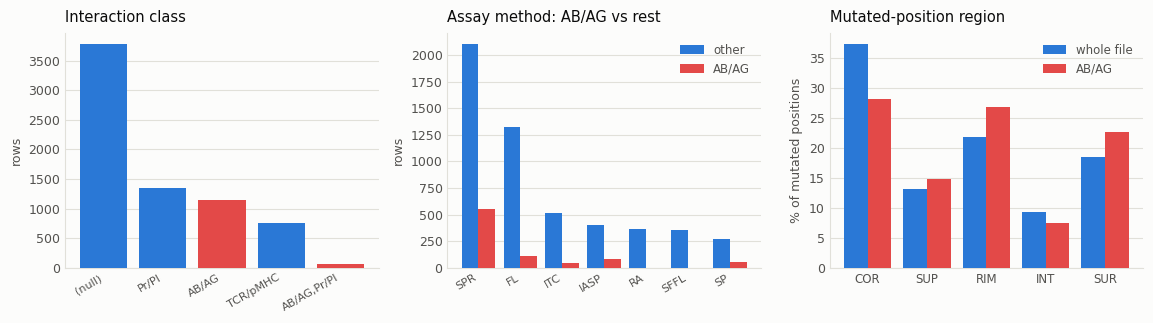

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.3))
_ax(axes[0], "Interaction class")
ht = raw["Hold_out_type"].fillna("(null)").value_counts()
axes[0].bar(range(len(ht)), ht.values,
            color=[RED if "AB/AG" in str(i) else BLUE for i in ht.index], zorder=3)
axes[0].set_xticks(range(len(ht)), ht.index, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("rows")

_ax(axes[1], "Assay method: AB/AG vs rest")
top_m = raw["Method"].value_counts().head(7).index
w = 0.4
for i, (d, c, lab) in enumerate([(raw[~raw.index.isin(ab.index)], BLUE, "other"),
                                 (ab, RED, "AB/AG")]):
    v = d["Method"].value_counts().reindex(top_m).fillna(0)
    axes[1].bar(np.arange(len(top_m)) + (i - 0.5) * w, v.values, width=w, color=c,
                label=lab, zorder=3)
axes[1].set_xticks(range(len(top_m)), top_m, rotation=30, ha="right", fontsize=8)
axes[1].legend(frameon=False, fontsize=8.5, labelcolor=INK_2); axes[1].set_ylabel("rows")

_ax(axes[2], "Mutated-position region")
for i, (d, c, lab) in enumerate([(raw, BLUE, "whole file"), (ab, RED, "AB/AG")]):
    loc = d["iMutation_Location(s)"].astype(str).str.split(",").explode().str.strip()
    v = loc.value_counts(normalize=True).reindex(["COR", "SUP", "RIM", "INT", "SUR"]).fillna(0)
    axes[2].bar(np.arange(5) + (i - 0.5) * w, v.values * 100, width=w, color=c, label=lab, zorder=3)
axes[2].set_xticks(range(5), ["COR", "SUP", "RIM", "INT", "SUR"], fontsize=8.5)
axes[2].set_ylabel("% of mutated positions")
axes[2].legend(frameon=False, fontsize=8.5, labelcolor=INK_2)
fig.tight_layout(); plt.show()

## 11. Summary — one line per column

`use here` records what this project does with each column, which is the bridge from this
notebook to [`../src/data.py`](../src/data.py).

In [30]:
USE = {
 "#Pdb": "identity; split unit; key into structures",
 "Mutation(s)_PDB": "NOT USED — wrong numbering for the distributed structures",
 "Mutation(s)_cleaned": "the mutation, parsed and verified against the PDB",
 "iMutation_Location(s)": "error-analysis slice; deliberately kept out of the chemistry rung",
 "Hold_out_type": "subset selection (AB/AG)",
 "Hold_out_proteins": "homology links for the clustered split (PDB-shaped tokens only)",
 "Affinity_mut (M)": "censoring flag (inequality / n.b.)",
 "Affinity_mut_parsed": "label numerator",
 "Affinity_wt (M)": "censoring flag",
 "Affinity_wt_parsed": "label denominator",
 "Temperature": "RT factor, plus an 'assumed' flag",
 "kon_mut (M^(-1)s^(-1))": "not used", "kon_mut_parsed": "not used",
 "kon_wt (M^(-1)s^(-1))": "not used", "kon_wt_parsed": "not used",
 "koff_mut (s^(-1))": "not used", "koff_mut_parsed": "not used",
 "koff_wt (s^(-1))": "not used", "koff_wt_parsed": "not used",
 "dH_mut (kcal mol^(-1))": "not used", "dH_wt (kcal mol^(-1))": "not used",
 "dS_mut (cal mol^(-1) K^(-1))": "not used", "dS_wt (cal mol^(-1) K^(-1))": "not used",
 "Reference": "carried; candidate leakage axis not yet closed",
 "Protein 1": "carried for readability only — roles come from structure",
 "Protein 2": "carried for readability only — roles come from structure",
 "Method": "error-analysis slice (label-noise proxy)",
 "Notes": "non-native reference state and near-identical flags",
 "SKEMPI version": "not used",
}
summary = pd.DataFrame([{
    "column": c,
    "what it is": DOCS[c][0].split(".")[0][:72],
    "populated": f"{100 * raw[c].notna().mean():.0f}%",
    "unique": raw[c].nunique(),
    "use here": USE[c],
} for c in raw.columns])
summary.style.hide(axis="index")

column,what it is,populated,unique,use here
#Pdb,"Complex identifier, formatted PDB__",100%,348,identity; split unit; key into structures
Mutation(s)_PDB,Mutation list in the numbering of the ORIGINAL PDB entry,100%,4707,NOT USED — wrong numbering for the distributed structures
Mutation(s)_cleaned,The same mutations renumbered to match the CLEANED structure files SKEMP,100%,5635,"the mutation, parsed and verified against the PDB"
iMutation_Location(s),"Structural region of each mutated position, one code per position: COR (",100%,487,error-analysis slice; deliberately kept out of the chemistry rung
Hold_out_type,"Interaction class: Pr/PI (protease-inhibitor), AB/AG (antibody-antigen),",47%,4,subset selection (AB/AG)
Hold_out_proteins,SKEMPI's own homology grouping: partner complexes that must be held out,100%,165,homology links for the clustered split (PDB-shaped tokens only)
Affinity_mut (M),"Dissociation constant Kd of the MUTANT complex, in molar, as free text",100%,2511,censoring flag (inequality / n.b.)
Affinity_mut_parsed,"Numeric Kd of the mutant, parsed from the text column",96%,2472,label numerator
Affinity_wt (M),"Dissociation constant of the WILD-TYPE complex, same text conventions",100%,466,censoring flag
Affinity_wt_parsed,Numeric Kd of the wild type,100%,464,label denominator


## Takeaways

1. **Nine columns carry the project.** `#Pdb`, `Mutation(s)_cleaned`, both parsed affinities,
   `Temperature`, `Hold_out_type`, `Hold_out_proteins`, `Method` and `Notes`. The twelve kinetic
   and calorimetric columns are too sparse to model on.
2. **The label has to be derived**, and its sign convention is a choice. Positive means weaker
   binding here.
3. **`Mutation(s)_cleaned` is the only mutation column that indexes the distributed structures.**
   The other one disagrees on two thirds of rows and fails silently.
4. **The two hold-out columns are one field expressed twice.** Parse `Hold_out_proteins` for
   PDB-shaped tokens and ignore the class strings inside it.
5. **Free text hides real caveats**: assumed temperatures, inequality affinities, `n.b.`
   non-binders, and curator notes that the "wild type" is itself an engineered variant.

Next: [`01_eda.ipynb`](01_eda.ipynb) applies this to the antibody–antigen subset and turns it
into modelling decisions.